## Vertical profile

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


In [2]:
SPEC = "/home/zhe2/FraLab/PACE_redSIF_PACE/surrogate_meas/output/profile_5511_spectra.nc"
ds   = xr.open_dataset(SPEC)
ds

2026-09-02 10:25:20,384 dedalus 0/1 WARNING :: Threading has not been disabled. This may massively degrade Dedalus performance.
2026-09-02 10:25:20,385 dedalus 0/1 WARNING :: We strongly suggest setting the "OMP_NUM_THREADS" environment variable to "1".


<xarray.Dataset> Size: 949kB
Dimensions:                (layer: 72, hres: 23201, band: 83, refl_band: 161)
Dimensions without coordinates: layer, hres, band, refl_band
Data variables: (12/33)
    layer_index            (layer) int32 288B ...
    pressure               (layer) float64 576B ...
    height                 (layer) float64 576B ...
    temperature            (layer) float64 576B ...
    vmr_h2o                (layer) float64 576B ...
    reflectance_weight     (layer) float64 576B ...
    ...                     ...
    residual               (band) float64 664B ...
    wavelength_refl        (refl_band) float64 1kB ...
    R_l1b                  (refl_band) float64 1kB ...
    R_legendre             (refl_band) float64 1kB ...
    R_legendre_rescaled    (refl_band) float64 1kB ...
    rho_legendre_rescaled  (refl_band) float64 1kB ...
Attributes: (12/20)
    title:                   Surrogate measurement spectra for plotting (prof...
    profile_index:           5511
    ps_hpa:                  1006.26
    stored_amf:              1.220774588761456
    sza_deg:                 30.0
    vza_deg:                 0.0
    ...                      ...
    retrieval_status:        1
    retrieval_converged:     1
    retrieval_rmse:          0.01901367451814325
    retrieval_reduced_chi2:  1.670053925358844
    retrieval_dof:           63.18509798706525
    created:                 2026-08-31T16:55:14.679

/tmp/ipykernel_2884271/1257479935.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


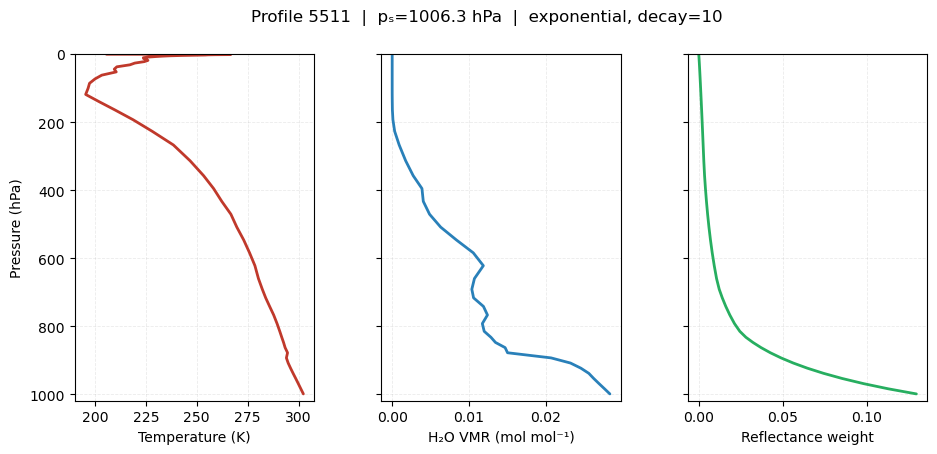

In [3]:
pressure = ds.pressure.values
temperature = ds.temperature.values
vmr_h2o = ds.vmr_h2o.values
reflectance_weight = ds.reflectance_weight.values

decay = float(ds.attrs.get("reflectance_decay", np.nan))
shape = ds.attrs.get("reflectance_shape", "exponential")
pid = int(ds.attrs.get("profile_index", -1))
ps = float(ds.attrs.get("ps_hpa", np.nan))

fig, ax = plt.subplots(
    1, 3, figsize=(11, 4.5), sharey=True,
    gridspec_kw={"wspace": 0.28},
)
panels = [
    (temperature, "Temperature", "K", "#c0392b"),
    (vmr_h2o, "H₂O VMR", "mol mol⁻¹", "#2980b9"),
    (reflectance_weight, "Reflectance weight", "−", "#27ae60"),
]

for a, (x, title, xunit, color) in zip(ax, panels):
    a.plot(x, pressure, color=color, lw=2.0, solid_capstyle="round")
    a.set_xlabel(f"{title} ({xunit})" if xunit != "−" else title)
    # a.set_title(title, fontsize=11, pad=8)
    a.grid(True, alpha=0.25, ls="--", lw=0.6)
    a.invert_yaxis()
    a.set_ylim(pressure.max() * 1.02, 0)

ax[0].set_ylabel("Pressure (hPa)")
for a in ax[1:]:
    a.tick_params(labelleft=False)

decay_txt = f", decay={decay:g}" if np.isfinite(decay) else ""
fig.suptitle(
    f"Profile {pid}  |  pₛ={ps:.1f} hPa  |  {shape}{decay_txt}",
    fontsize=12, y=0.98,
)
fig.tight_layout()
plt.show()

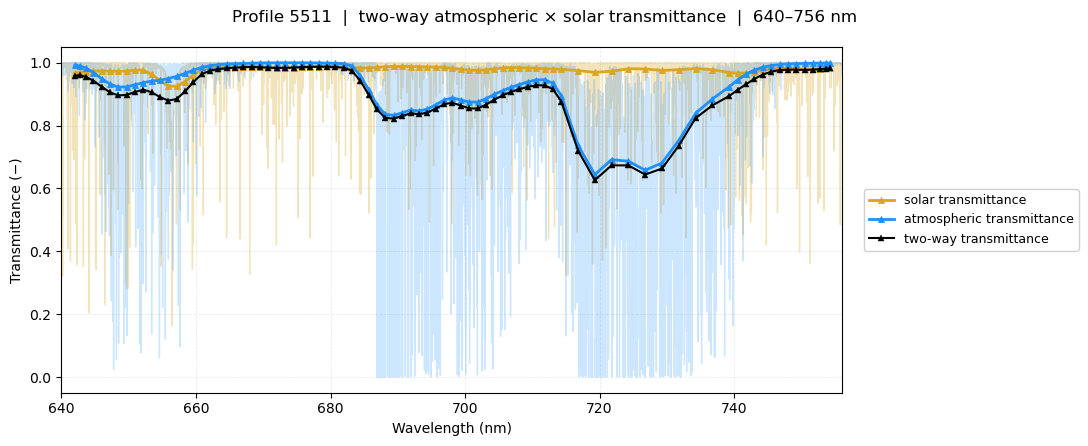

In [4]:
# hi-res (convolution grid) and OCI band means
wl_h = ds.wavelength_hres.values
T_solar_h = ds.T_solar_hres.values
T2_atm_h = ds.T2_atm_hres.values

wl_b = ds.wavelength.values
T_solar_b = ds.T_solar.values
T2_atm_b = ds.T2_atm.values
T2_b = ds.T2.values

pid = int(ds.attrs.get("profile_index", -1))
wl_min, wl_max = wl_h.min(), wl_h.max()

fig, ax = plt.subplots(figsize=(11, 4.5))

# hi-res background (light)
ax.plot(wl_h, T_solar_h, color="#DAA520", lw=1.0, alpha=0.30)
ax.plot(wl_h, T2_atm_h, color="#1E90FF", lw=1.0, alpha=0.22)

# OCI band means (emphasis)
ms = 4
ax.plot(
    wl_b, T_solar_b, color="#DAA520", lw=2.0, marker="^", ms=ms,
    mfc="#DAA520", mew=0.6, label="solar transmittance",
)
ax.plot(
    wl_b, T2_atm_b, color="#1E90FF", lw=2.0, marker="^", ms=ms,
    mfc="#1E90FF", mew=0.6, label="atmospheric transmittance",
)
ax.plot(
    wl_b, T2_b, color="k", lw=1.5, marker="^", ms=ms + 1,
    mfc="k", mew=0.3, label="two-way transmittance",
)

ax.set_xlim(wl_min, wl_max)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Transmittance (−)")
ax.grid(True, alpha=0.25, ls="--", lw=0.6)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), framealpha=0.92, fontsize=9)
fig.suptitle(
    f"Profile {pid}  |  two-way atmospheric × solar transmittance  |  "
    f"{wl_min:.0f}–{wl_max:.0f} nm",
    fontsize=12, y=0.98,
)
fig.tight_layout()
plt.show()


In [5]:
# Spectra (create x fitted)
wl_b = ds.wavelength.values
R_toa_noisy = ds.R_toa_noisy.values
R_fit = ds.R_fit.values
SIF = ds.SIF.values
SIF_toa_fit = ds.SIF_toa_fit.values
residual = ds.residual.values
noise_sigma = ds.noise_sigma.values

BASELINE_λ_REF = [
    602.918, 612.732, 617.605, 620.06, 622.53, 639.79,
    662.068, 665.795, 668.265, 669.518, 670.755, 673.245,
    675.73, 678.205, 679.445, 680.68, 681.918, 745.535,
    748.04, 754.295, 773.075, 774.337, 776.832, 779.335,
    781.842, 859.595, 862.112,
]

# Nearest OCI band for each baseline ref (same logic as baseline_band_indices in build_single_meas.jl)
data_lo, data_hi = wl_b.min(), wl_b.max()
baseline_refs = [r for r in BASELINE_λ_REF if data_lo - 2.0 <= r <= data_hi + 2.0]

baseline_idx = []
baseline_wl = []
baseline_delta = []
for r in baseline_refs:
    i = int(np.argmin(np.abs(wl_b - r)))
    d = abs(wl_b[i] - r)
    if d > 0.2:
        print(f"warning: ref {r:.3f} nm → nearest band {wl_b[i]:.3f} nm (Δ={d:.2f} nm)")
    baseline_idx.append(i)
    baseline_wl.append(wl_b[i])
    baseline_delta.append(d)

# drop duplicate band indices (multiple refs can map to the same band)
_, uniq = np.unique(baseline_idx, return_index=True)
baseline_idx = [baseline_idx[j] for j in sorted(uniq)]
baseline_wl = wl_b[baseline_idx]
baseline_refs_used = [baseline_refs[j] for j in sorted(uniq)]

print(f"{len(baseline_refs_used)} baseline bands in [{data_lo:.1f}, {data_hi:.1f}] nm "
      f"(from {len(BASELINE_λ_REF)} refs)")


14 baseline bands in [642.0, 754.2] nm (from 27 refs)


/tmp/ipykernel_2884271/3046513511.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


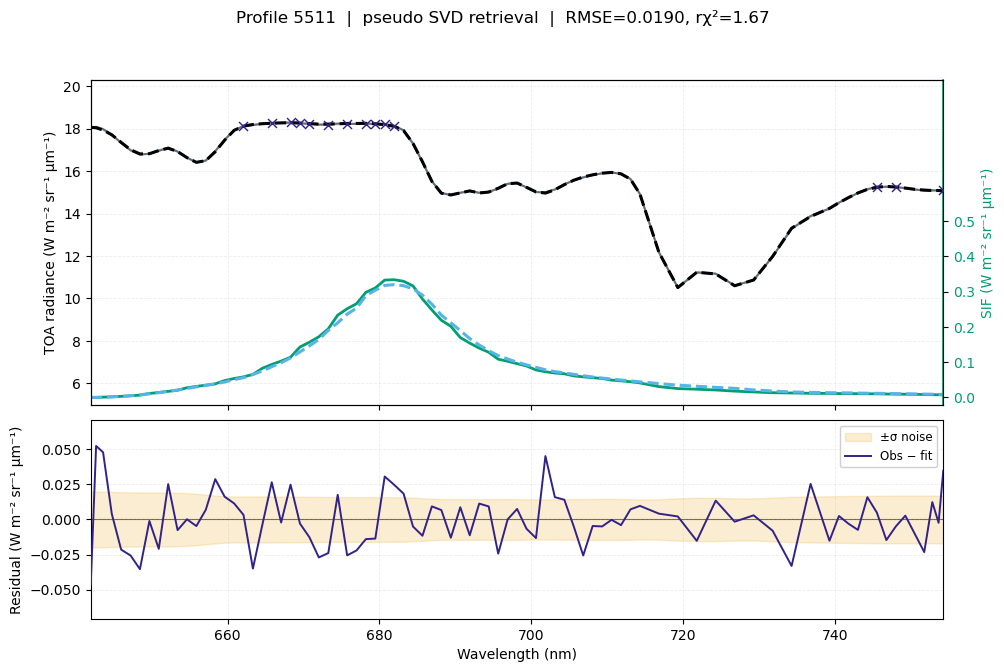

In [6]:
# TOA + SIF (twin axis) and residual QA
pid = int(ds.attrs.get("profile_index", -1))
rmse = float(ds.attrs.get("retrieval_rmse", np.nan))
rchi2 = float(ds.attrs.get("retrieval_reduced_chi2", np.nan))
R_toa_clean = ds.R_toa_clean.values
SIF_toa = ds.SIF_toa.values

C_TOA_OBS = "#666666"
C_TOA_TRUE = "#0072B2"
C_TOA_FIT = "k"
C_SIF_TRUE = "#009E73"
C_SIF_FIT = "#56B4E9"
C_BASELINE = "#332288"
C_RESID = "#332288"
C_SIGMA = "#E69F00"

wl_min, wl_max = wl_b.min(), wl_b.max()
sif_max = max(SIF_toa.max(), SIF_toa_fit.max())
res_lim = max(np.abs(residual).max(), np.nanmax(noise_sigma)) * 1.35

fig, (ax_top, ax_res) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True,
    gridspec_kw={"height_ratios": [1.8, 1.1], "hspace": 0.06},
)

# (a) TOA radiance (left) + SIF @ TOA (right)
ax_toa = ax_top
ax_toa.plot(
    wl_b, R_toa_clean, color=C_TOA_TRUE, lw=1.5, alpha=0.55,
    label="True TOA (clean)", zorder=1,
)
(l_obs,) = ax_toa.plot(
    wl_b, R_toa_noisy, color=C_TOA_OBS, lw=1.4, alpha=0.90,
    label="Observed (+ noise)", zorder=2,
)
(l_fit,) = ax_toa.plot(
    wl_b, R_fit, color=C_TOA_FIT, lw=2.2, ls="--",
    label="SVD fit", zorder=3,
)
sc_base = ax_toa.scatter(
    baseline_wl, R_toa_noisy[baseline_idx], s=42, marker="x",
    c=C_BASELINE, linewidths=1.0, zorder=4, label="Baseline bands",
)
ax_toa.set_xlim(wl_min, wl_max)
ax_toa.set_ylim(5.0, R_toa_noisy.max() + 2.0)
ax_toa.set_ylabel("TOA radiance (W m⁻² sr⁻¹ µm⁻¹)", color=C_TOA_FIT)
ax_toa.tick_params(axis="y", labelcolor=C_TOA_FIT)
# ax_toa.set_title("(a) TOA radiance & SIF @ TOA", loc="left", fontsize=10, pad=4)
ax_toa.grid(True, alpha=0.22, ls="--", lw=0.6, zorder=0)

ax_sif = ax_toa.twinx()
(l_sif_true,) = ax_sif.plot(
    wl_b, SIF_toa, color=C_SIF_TRUE, lw=2.0,
    label="True SIF×T₁", zorder=1,
)
(l_sif_fit,) = ax_sif.plot(
    wl_b, SIF_toa_fit, color=C_SIF_FIT, lw=2.2, ls="--",
    label="Retrieved SIF×T₁", zorder=1,
)
ax_sif.set_ylim(-0.02, max(0.90, sif_max * 1.25))
ax_sif.set_ylabel("SIF (W m⁻² sr⁻¹ µm⁻¹)", color=C_SIF_TRUE)
ax_sif.set_yticks(np.arange(0, 0.55, 0.1))
ax_sif.tick_params(axis="y", labelcolor=C_SIF_TRUE)
ax_sif.spines["right"].set_color(C_SIF_TRUE)
ax_sif.spines["right"].set_linewidth(1.2)

ax_toa.set_zorder(2)
ax_toa.patch.set_visible(False)
# ax_toa.legend(
#     [l_true, l_obs, l_fit, l_sif_true, l_sif_fit, sc_base],
#     [h.get_label() for h in (l_true, l_obs, l_fit, l_sif_true, l_sif_fit, sc_base)],
#     loc="upper right", framealpha=0.92, fontsize=8.5, handlelength=2.2,
# )

# (b) Residual vs noise σ
ax_res.axhline(0.0, color="0.35", lw=0.8, zorder=1)
ax_res.fill_between(
    wl_b, -noise_sigma, noise_sigma,
    color=C_SIGMA, alpha=0.18, label="±σ noise", zorder=1,
)
(l_res,) = ax_res.plot(
    wl_b, residual, color=C_RESID, lw=1.4,
    label="Obs − fit", zorder=3,
)
ax_res.set_ylim(-res_lim, res_lim)
ax_res.set_xlabel("Wavelength (nm)")
ax_res.set_ylabel("Residual (W m⁻² sr⁻¹ µm⁻¹)")
# ax_res.set_title("(b) Residual vs. noise σ", loc="left", fontsize=10, pad=4)
ax_res.grid(True, alpha=0.22, ls="--", lw=0.6)
ax_res.legend(loc="upper right", framealpha=0.92, fontsize=8.5, handlelength=2.2)

rmse_txt = f"RMSE={rmse:.4f}" if np.isfinite(rmse) else "RMSE=—"
rchi2_txt = f"rχ²={rchi2:.2f}" if np.isfinite(rchi2) else "rχ²=—"
fig.suptitle(
    f"Profile {pid}  |  pseudo SVD retrieval  |  {rmse_txt}, {rchi2_txt}",
    fontsize=12, y=0.98,
)
fig.tight_layout()
plt.show()


/home/zhe2/anaconda3/envs/ocean/lib/python3.14/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'state'} appear more than once in dims=('sample', 'state', 'state'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
/home/zhe2/anaconda3/envs/ocean/lib/python3.14/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'state'} appear more than once in dims=('sample', 'state', 'state'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become d

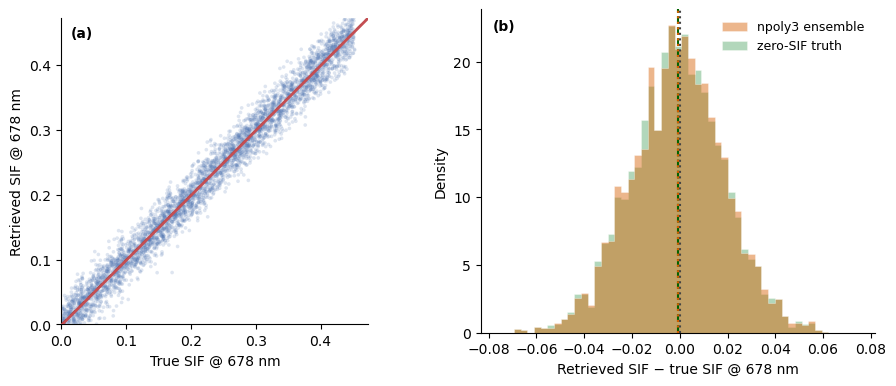

(a)  npoly3, n=4,166
bias = -0.001
RMSE = 0.019
R² = 0.978
slope = 1.001


In [7]:
# Ensemble SIF@678 — scatter + error PDF (npoly3 vs zero-SIF floor)
npoly3 = xr.open_dataset(
    "/home/zhe2/FraLab/PACE_redSIF_PACE/surrogate_meas/batch_ensemble/retrieval_ensemble_npoly3_nPC10.nc",
)
npoly3_zero = xr.open_dataset(
    "/home/zhe2/FraLab/PACE_redSIF_PACE/surrogate_meas/batch_ensemble/retrieval_ensemble_npoly3_zeroSIF_nPC10.nc",
)

def _conv_mask(ds):
    return ds.converged.values.astype(bool) if "converged" in ds else ds.status.values == 1

ok = _conv_mask(npoly3)
ok0 = _conv_mask(npoly3_zero)

t678 = npoly3.sif_678_true.values[ok]
r678 = npoly3.sif_678_ret.values[ok]
delta = r678 - t678
delta0 = (
    npoly3_zero.sif_678_ret.values[ok0]
    - npoly3_zero.sif_678_true.values[ok0]
)

bias = delta.mean()
rmse = np.sqrt(np.mean(delta**2))
r2 = 1.0 - np.sum(delta**2) / np.sum((r678 - r678.mean())**2)
slope, intercept = np.polyfit(t678, r678, 1)

lo, hi = np.percentile(np.concatenate([t678, r678]), [0.5, 99.5])
pad = 0.04 * (hi - lo + 1e-9)
lims = (max(0.0, lo - pad), hi + pad)

# colors
C_PT = "#4C72B0"
C_FIT = "#C44E52"
C_ONE = "#444444"
C_MAIN = "#D55E00"
C_FLOOR = "#55A868"
C_MEDIAN = C_MAIN
C_MEDIAN0 = "darkgreen"

with plt.rc_context({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}):
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(10.5, 4.2),
        gridspec_kw={"width_ratios": [1.05, 1.35], "wspace": 0.32},
        tight_layout=True,
    )

    # (a) scatter
    ax1.scatter(
        t678, r678, s=7, alpha=0.18, c=C_PT,
        edgecolors="none", rasterized=True, zorder=1,
    )
    ax1.plot(lims, lims, color=C_ONE, ls=(0, (4, 3)), lw=1.3, zorder=2)
    xx = np.linspace(lims[0], lims[1], 100)
    ax1.plot(xx, slope * xx + intercept, color=C_FIT, lw=2.0, zorder=3)
    ax1.set_xlim(lims)
    ax1.set_ylim(lims)
    ax1.set_aspect("equal", adjustable="box")
    ax1.set_xlabel("True SIF @ 678 nm")
    ax1.set_ylabel("Retrieved SIF @ 678 nm")
    ax1.text(
        0.03, 0.97,
        f"(a)",
        fontweight="bold",
        transform=ax1.transAxes, va="top", ha="left", fontsize=10,
        # bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.85", alpha=0.95),
    )

    # (b) error histograms — zoom to bulk of errors
    xlo, xhi = np.percentile(np.concatenate([delta, delta0]), [0.5, 99.5])
    xpad = 0.3 * (xhi - xlo + 1e-9)
    bins = np.linspace(xlo - xpad, xhi + xpad, 60)

    ax2.hist(
        delta, bins=bins, density=True, histtype="stepfilled",
        color=C_MAIN, alpha=0.45, edgecolor="white", linewidth=0.5,
        label="npoly3 ensemble", zorder=2,
    )
    ax2.hist(
        delta0, bins=bins, density=True, histtype="stepfilled",
        color=C_FLOOR, alpha=0.45, edgecolor="white", linewidth=0.5,
        label="zero-SIF truth", zorder=1,
    )
    ax2.axvline(0.0, color=C_ONE, lw=1.5, ls=":", zorder=3)
    ax2.axvline(np.median(delta), color=C_MEDIAN, lw=1.5, ls=":", zorder=4)
    ax2.axvline(np.median(delta0), color=C_MEDIAN0, lw=1.5, ls="--", zorder=3)
    ax2.set_xlim(xlo - xpad, xhi + xpad)
    ax2.set_xlabel("Retrieved SIF − true SIF @ 678 nm")
    ax2.set_ylabel("Density")
    ax2.text(0.03, 0.97, "(b)", transform=ax2.transAxes, va="top", ha="left", fontsize=10, fontweight="bold")
    ax2.legend(loc="upper right", frameon=False, fontsize=9)

    # fig.suptitle("Surrogate ensemble · npoly3 · decay ∈ [4, 12]", fontsize=12, y=1.04)
    plt.show()

print(f"(a)  npoly3, n={ok.sum():,}\n"
        f"bias = {bias:+.3f}\n"
        f"RMSE = {rmse:.3f}\n"
        f"R² = {r2:.3f}\n"
        f"slope = {slope:.3f}")

### Inspect averaging kernel

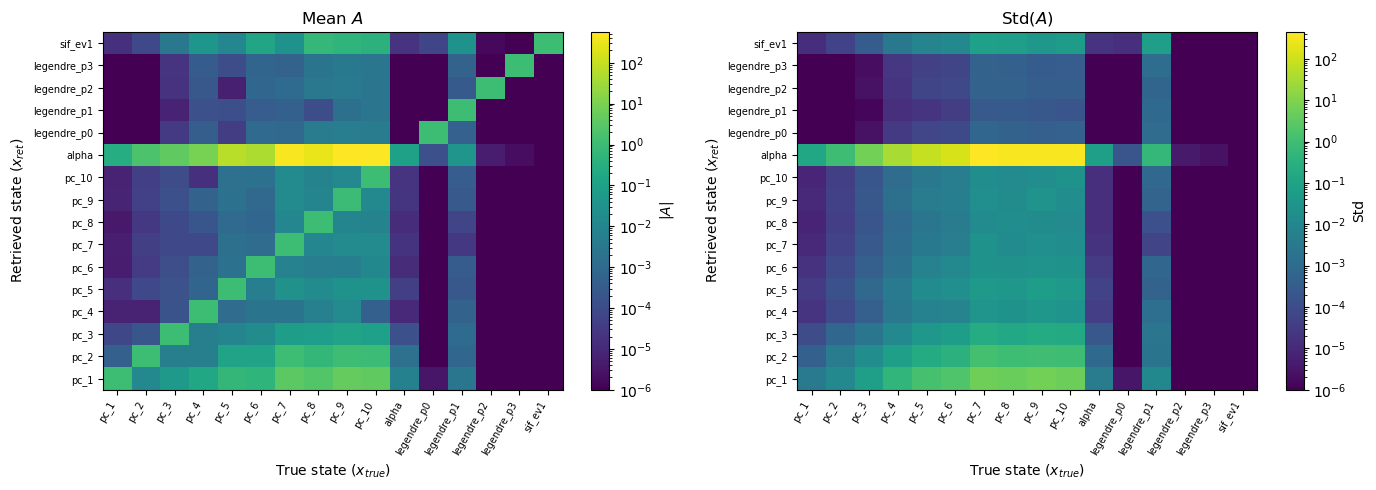

In [8]:
# Averaging kernel A = S_post * H_obs  (Rodgers: A[i,j] = d x_ret_i / d x_true_j)
# Julia NetCDF: averaging_kernel(state_ret, state_true, sample)
# xarray loads (sample, state, state) with duplicate dim names; the 2D slice is
# transposed vs Julia, so we .T after averaging over converged samples.
state_names = npoly3.attrs["state_names_csv"].split(",")
n_state = len(state_names)
state_ticks = np.arange(n_state) + 0.5

ak = npoly3["averaging_kernel"].values[ok].mean(axis=0).T  # [retrieved, true]
ak_std = npoly3["averaging_kernel"].values[ok].std(axis=0).T

from matplotlib.colors import LogNorm

_log_floor = 1e-6

def _plot_ak_panel(ax, data, title, cbar_label):
    im = ax.pcolormesh(
        np.maximum(np.abs(data), _log_floor),
        cmap="viridis",
        norm=LogNorm(vmin=_log_floor, vmax=max(np.abs(data).max(), _log_floor)),
    )
    ax.set_title(title)
    ax.set_xlabel(r"True state ($x_{true}$)")
    ax.set_ylabel(r"Retrieved state ($x_{ret}$)")
    ax.set_xticks(state_ticks)
    ax.set_xticklabels(state_names, rotation=60, ha="right", fontsize=7)
    ax.set_yticks(state_ticks)
    ax.set_yticklabels(state_names, fontsize=7)
    fig.colorbar(im, ax=ax, label=cbar_label)
    return im

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
_plot_ak_panel(ax1, ak, r"Mean $A$", r"$|A|$")
_plot_ak_panel(ax2, ak_std, r"Std($A$)", "Std")
plt.tight_layout()